Импортируем pandas и подгружаем датасет

In [156]:
import pandas as pd

df = pd.read_csv('Iris.csv')

Видно, что у нас есть 6 столбцов и 150 строк

In [157]:
df.shape

(150, 6)

Среди столбцов имеем:
0\. id - целое значение
1-4.размеры в сантиметрах, float
5\. вид, строковое значение 

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Видим, что в датасете нет пропусков

In [159]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Есть три вида ириса

<Axes: xlabel='Species'>

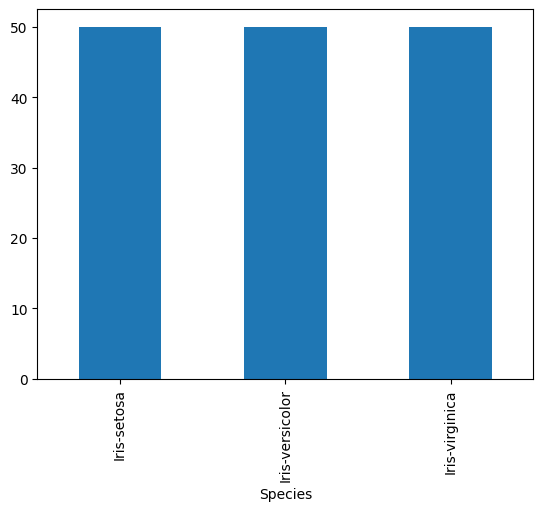

In [160]:
df['Species'].value_counts().plot(kind='bar')

Как видно, нет дубликатов.
Смотрим описание, чтобы увидеть странности в средних значениях(например, mean = -150 для цены было бы странно)

In [161]:
print("Duplicate rows:", df.duplicated().sum())
print("Description:\n", df.describe().to_string())

Duplicate rows: 0
Description:
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


Нормализуем, используя `MinMaxScaler`
Масштабировать данные нужно обязательно, так как ширина, например, может измеряться в диапазоне 1-3 см, а длина 10-20 см. И так как метрики зависят от этих координат, то без нормализации данных модель длина будет вносить больший вклад, чем ширина, так как ее значения сами по себе больше.

In [162]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

Разделим данные на features (x) и labels (y)
Закодируем y через `LabelEncoder`

In [163]:
y = df['Species']
y_encoded = pd.Series(LabelEncoder().fit_transform(y))
x = df.drop(['Id','Species'], axis=1)[['PetalLengthCm', 'PetalWidthCm']]
print(x.head())
print(y_encoded[:5])

   PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2
0    0
1    0
2    0
3    0
4    0
dtype: int64


In [164]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
print("Scaled Features:\n", x_scaled[:5])  # Display the first 5 scaled rows

Scaled Features:
 [[0.06779661 0.04166667]
 [0.06779661 0.04166667]
 [0.05084746 0.04166667]
 [0.08474576 0.04166667]
 [0.06779661 0.04166667]]


Разделим датасет на train/test

In [165]:
from sklearn.model_selection import train_test_split

In [166]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_encoded, test_size=0.2, random_state=97)

Пора обучить модель KNN. Используем KNearestNeighbors из sk-learn

In [167]:
from sklearn.neighbors import KNeighborsClassifier

In [168]:
knn = KNeighborsClassifier(n_neighbors=5)
model = knn.fit(x_train, y_train)

In [169]:
x_predicted = model.predict(x_test)
print(x_predicted)

[0 0 1 1 2 1 0 1 0 2 1 0 1 1 2 2 2 2 2 0 0 0 2 2 1 1 0 2 1 2]


In [170]:
import matplotlib.pyplot as plt
import numpy as np

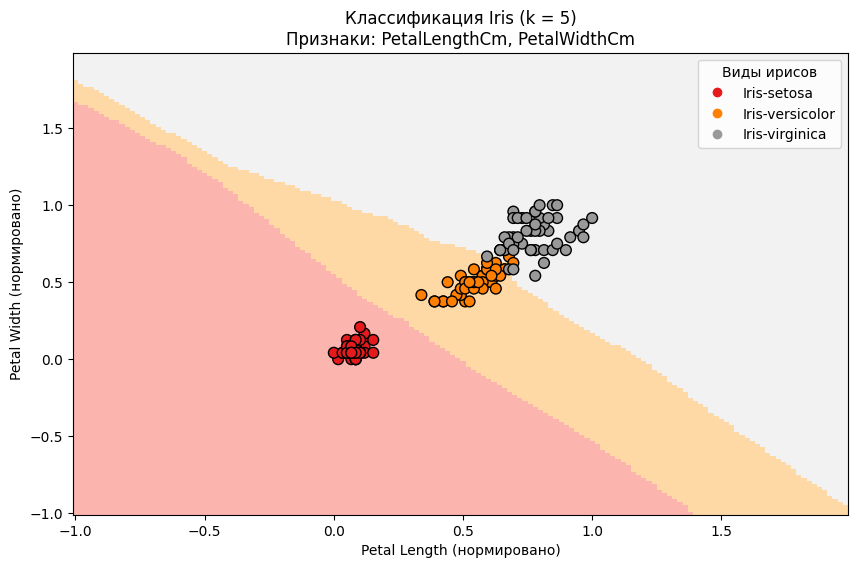

In [171]:
h = .02  # step size in the mesh
x_min, x_max = x_scaled[:, 0].min() - 1, x_scaled[:, 0].max() + 1
y_min, y_max = x_scaled[:, 1].min() - 1, x_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

plt.pcolormesh(xx, yy, Z, cmap='Pastel1', shading='auto')

scatter = plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_encoded, 
            edgecolors='k', cmap='Set1', s=60)

# Оформление
plt.title(f"Классификация Iris (k = {model.n_neighbors})\nПризнаки: {', '.join(x.columns.tolist())}")
plt.xlabel("Petal Length (нормировано)")
plt.ylabel("Petal Width (нормировано)")

# Добавляем легенду с названиями видов
handles, _ = scatter.legend_elements()
plt.legend(handles, y.unique(), title="Виды ирисов")

plt.show()